# Notebook 2 — Feature Selection

**Input:** `combined_labeled.csv` (84 features + Label)

**Output:** `combined_features.csv` (52 features + Label)

---

## What gets dropped and why

| Stage | Columns Dropped | Remaining |
|---|---|---|
| Start | — | 84 features |
| 2A — Metadata | 4 cols (Flow ID, Source IP, Destination IP, Timestamp) | 80 features |
| 2B — Zero variance | 10 cols (always 0, no information) | 70 features |
| 2C — High correlation | 18 cols (>0.98 corr, near-duplicates) | **52 features** |

---

### 2A — Metadata columns (never use as features)
| Column | Reason |
|---|---|
| `Flow ID` | Unique identifier — random string, zero signal |
| `Source IP` | Model would memorize lab attacker IPs, fail on real traffic |
| `Destination IP` | Same reason |
| `Timestamp` | Time of capture — not a network behavior feature |

### 2B — Zero-variance columns (always 0)
| Column | Why |
|---|---|
| `Bwd PSH Flags` | Always 0 in entire dataset |
| `Fwd URG Flags` | Always 0 |
| `Bwd URG Flags` | Always 0 |
| `CWE Flag Count` | Always 0 |
| `Fwd Avg Bytes/Bulk` | Always 0 |
| `Fwd Avg Packets/Bulk` | Always 0 |
| `Fwd Avg Bulk Rate` | Always 0 |
| `Bwd Avg Bytes/Bulk` | Always 0 |
| `Bwd Avg Packets/Bulk` | Always 0 |
| `Bwd Avg Bulk Rate` | Always 0 |

### 2C — Highly correlated columns (>0.98, near-duplicates)
| Drop | Duplicates |
|---|---|
| `Fwd Packet Length Std` | `Fwd Packet Length Mean` |
| `Bwd Packet Length Std` | `Bwd Packet Length Mean` |
| `Fwd IAT Total` | `Fwd IAT Mean` |
| `Fwd IAT Max` | `Flow IAT Max` |
| `Fwd Packets/s` | `Flow Packets/s` |
| `Packet Length Std` | `Packet Length Variance` |
| `SYN Flag Count` | `RST Flag Count` pattern |
| `ECE Flag Count` | `ACK Flag Count` |
| `Average Packet Size` | `Packet Length Mean` |
| `Avg Fwd Segment Size` | `Fwd Packet Length Mean` |
| `Avg Bwd Segment Size` | `Bwd Packet Length Mean` |
| `Fwd Header Length.1` | Exact duplicate of `Fwd Header Length` |
| `Subflow Fwd Packets` | `Total Fwd Packets` |
| `Subflow Fwd Bytes` | `Total Length of Fwd Packets` |
| `Subflow Bwd Packets` | `Total Backward Packets` |
| `Subflow Bwd Bytes` | `Total Length of Bwd Packets` |
| `Active Min` | `Active Mean` |
| `Idle Max` | `Idle Mean` |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

CSV_PATH = r'D:\Computer Engineering 2022\4-CE.Z Forth Year\second-semester-4.2\project\ML-NIDS-Android\03-dataset\02-processed\02_combined_labeled.csv'

df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()
print(f'Loaded shape: {df.shape}')

Loaded shape: (2827829, 85)


In [2]:
# ── 2A: Drop metadata columns ─────────────────────────────────────────────────
META_COLS = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
existing_meta = [c for c in META_COLS if c in df.columns]
df.drop(columns=existing_meta, inplace=True)
print(f'After dropping metadata ({len(existing_meta)} cols): {df.shape}')

After dropping metadata (4 cols): (2827829, 81)


In [3]:
# ── 2B: Drop zero-variance columns ───────────────────────────────────────────
ZERO_VAR_COLS = [
    'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count',
    'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate',
    'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate'
]

# Verify they are actually zero variance
feature_cols = [c for c in df.columns if c != 'Label']
actual_zero_var = df[feature_cols].columns[df[feature_cols].std() == 0].tolist()
print(f'Columns confirmed zero-variance in your data: {actual_zero_var}')

existing_zv = [c for c in ZERO_VAR_COLS if c in df.columns]
df.drop(columns=existing_zv, inplace=True)
print(f'After dropping zero-variance ({len(existing_zv)} cols): {df.shape}')

Columns confirmed zero-variance in your data: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
After dropping zero-variance (10 cols): (2827829, 71)


In [4]:
# ── 2C: Visualize correlation heatmap BEFORE dropping ─────────────────────────
feature_cols = [c for c in df.columns if c != 'Label']
corr_matrix  = df[feature_cols].corr().abs()

# Find pairs with correlation > 0.98
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.98:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                round(corr_matrix.iloc[i, j], 4)
            ))

print(f'Pairs with correlation > 0.98: {len(high_corr_pairs)}')
for a, b, v in high_corr_pairs:
    print(f'  {v:.4f}  {a}  ↔  {b}')

Pairs with correlation > 0.98: 31
  0.9986  Flow Duration  ↔  Fwd IAT Total
  0.9991  Total Fwd Packets  ↔  Total Backward Packets
  0.9970  Total Fwd Packets  ↔  Total Length of Bwd Packets
  1.0000  Total Fwd Packets  ↔  Subflow Fwd Packets
  0.9991  Total Fwd Packets  ↔  Subflow Bwd Packets
  0.9970  Total Fwd Packets  ↔  Subflow Bwd Bytes
  0.9945  Total Backward Packets  ↔  Total Length of Bwd Packets
  0.9991  Total Backward Packets  ↔  Subflow Fwd Packets
  1.0000  Total Backward Packets  ↔  Subflow Bwd Packets
  0.9944  Total Backward Packets  ↔  Subflow Bwd Bytes
  1.0000  Total Length of Fwd Packets  ↔  Subflow Fwd Bytes
  0.9970  Total Length of Bwd Packets  ↔  Subflow Fwd Packets
  0.9945  Total Length of Bwd Packets  ↔  Subflow Bwd Packets
  1.0000  Total Length of Bwd Packets  ↔  Subflow Bwd Bytes
  1.0000  Fwd Packet Length Mean  ↔  Avg Fwd Segment Size
  0.9828  Bwd Packet Length Max  ↔  Bwd Packet Length Std
  1.0000  Bwd Packet Length Mean  ↔  Avg Bwd Segment Size
  0

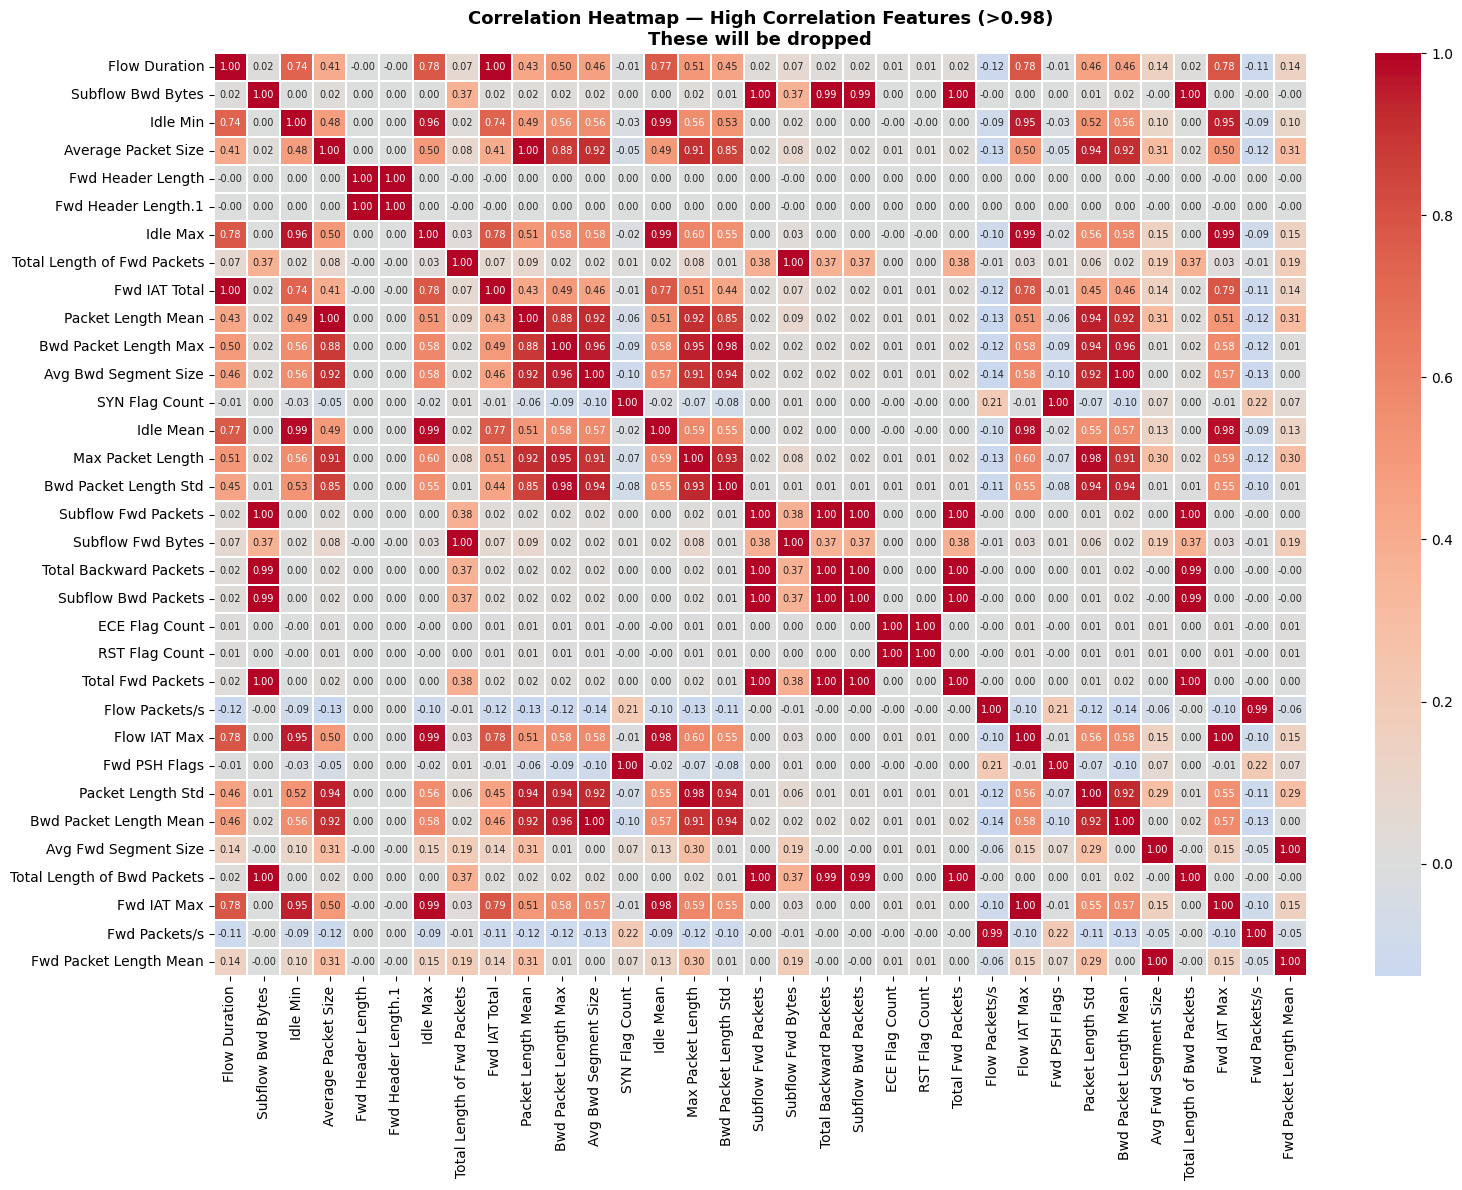

Saved 02_correlation_heatmap.png


In [5]:
# Plot correlation heatmap of high-corr features only
high_corr_cols = list(set([a for a,b,v in high_corr_pairs] + [b for a,b,v in high_corr_pairs]))

if len(high_corr_cols) > 0:
    plt.figure(figsize=(16, 12))
    sns.heatmap(
        df[high_corr_cols].corr(),
        annot=True, fmt='.2f', cmap='coolwarm',
        center=0, linewidths=0.3, annot_kws={'size': 7}
    )
    plt.title('Correlation Heatmap — High Correlation Features (>0.98)\nThese will be dropped', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('02_correlation_heatmap.png', dpi=150)
    plt.show()
    print('Saved 02_correlation_heatmap.png')

In [6]:
# ── 2C: Drop high-correlation columns ────────────────────────────────────────
HIGH_CORR_COLS = [
    'Fwd Packet Length Std', 'Bwd Packet Length Std',
    'Fwd IAT Total', 'Fwd IAT Max',
    'Fwd Packets/s', 'Packet Length Std',
    'SYN Flag Count', 'ECE Flag Count',
    'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size',
    'Fwd Header Length.1',
    'Subflow Fwd Packets', 'Subflow Fwd Bytes',
    'Subflow Bwd Packets', 'Subflow Bwd Bytes',
    'Active Min', 'Idle Max'
]
existing_hc = [c for c in HIGH_CORR_COLS if c in df.columns]
df.drop(columns=existing_hc, inplace=True)
print(f'After dropping high-correlation ({len(existing_hc)} cols): {df.shape}')

FEATURE_COLS = [c for c in df.columns if c != 'Label']
print(f'\nFinal feature count: {len(FEATURE_COLS)}')
print('Features kept:')
for i, f in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2}. {f}')

After dropping high-correlation (18 cols): (2827829, 53)

Final feature count: 52
Features kept:
   1. Source Port
   2. Destination Port
   3. Protocol
   4. Flow Duration
   5. Total Fwd Packets
   6. Total Backward Packets
   7. Total Length of Fwd Packets
   8. Total Length of Bwd Packets
   9. Fwd Packet Length Max
  10. Fwd Packet Length Min
  11. Fwd Packet Length Mean
  12. Bwd Packet Length Max
  13. Bwd Packet Length Min
  14. Bwd Packet Length Mean
  15. Flow Bytes/s
  16. Flow Packets/s
  17. Flow IAT Mean
  18. Flow IAT Std
  19. Flow IAT Max
  20. Flow IAT Min
  21. Fwd IAT Mean
  22. Fwd IAT Std
  23. Fwd IAT Min
  24. Bwd IAT Total
  25. Bwd IAT Mean
  26. Bwd IAT Std
  27. Bwd IAT Max
  28. Bwd IAT Min
  29. Fwd PSH Flags
  30. Fwd Header Length
  31. Bwd Header Length
  32. Bwd Packets/s
  33. Min Packet Length
  34. Max Packet Length
  35. Packet Length Mean
  36. Packet Length Variance
  37. FIN Flag Count
  38. RST Flag Count
  39. PSH Flag Count
  40. ACK Flag Cou

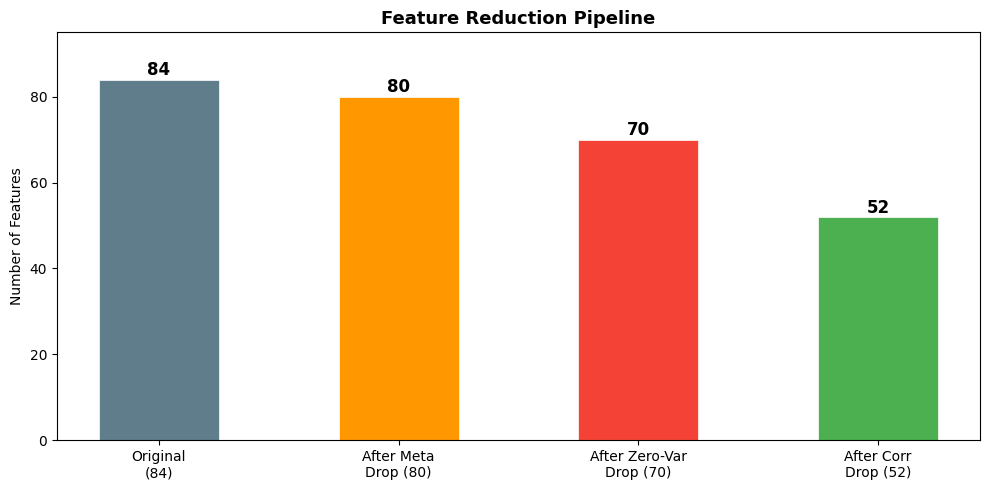

Saved 02_feature_reduction.png


In [7]:
# Plot: features dropped at each stage
stages  = ['Original\n(84)', 'After Meta\nDrop (80)', 'After Zero-Var\nDrop (70)', 'After Corr\nDrop (52)']
counts  = [84, 80, 70, 52]
colors  = ['#607D8B', '#FF9800', '#F44336', '#4CAF50']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(stages, counts, color=colors, edgecolor='white', linewidth=0.5, width=0.5)
ax.set_ylim(0, 95)
ax.set_ylabel('Number of Features')
ax.set_title('Feature Reduction Pipeline', fontsize=13, fontweight='bold')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(count), ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('02_feature_reduction.png', dpi=150)
plt.show()
print('Saved 02_feature_reduction.png')

In [8]:
# Save
import os
OUT_PATH = os.path.join(os.path.dirname(CSV_PATH), 'combined_features.csv')
df.to_csv(OUT_PATH, index=False)
print(f'Saved → {OUT_PATH}')
print(f'Final shape: {df.shape}')

Saved → D:\Computer Engineering 2022\4-CE.Z Forth Year\second-semester-4.2\project\ML-NIDS-Android\03-dataset\02-processed\combined_features.csv
Final shape: (2827829, 53)
